# Local LLM Daily Task Analysis

Analysis of GPT-4o annotated Reddit posts and comments from `reddit_annotated.csv`.

**Taxonomy** (4 themes · 10 sub-themes)

| Theme | Sub-themes |
|---|---|
| Creation | Artifact · Idea |
| Information Search | Search · Learn · Summarize · Analyze |
| Advice | Improve · Guidance · Validation |
| Automation | Automation |

**Two streams**
- Stream 1 — small / local LLMs  
- Stream 2 — large / general LLMs

In [1]:
import re
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

THEMES    = ['Creation', 'Information Search', 'Advice', 'Automation']
SUBTHEMES = {
    'Creation':           ['Artifact', 'Idea'],
    'Information Search': ['Search', 'Learn', 'Summarize', 'Analyze'],
    'Advice':             ['Improve', 'Guidance', 'Validation'],
    'Automation':         ['Automation'],
}
ALL_SUBTHEMES = [st for subs in SUBTHEMES.values() for st in subs]

# colour palette — one per theme
THEME_COLORS = {
    'Creation':           '#4A90D9',
    'Information Search': '#27AE60',
    'Advice':             '#E67E22',
    'Automation':         '#8E44AD',
}

# Stream 1 = SLM (small / local language models)
# Stream 2 = LLM (large / general language models)
CSV_PATH_SLM = Path('reddit_annotated_stream1.csv')
CSV_PATH_LLM = Path('reddit_annotated_stream2.csv')
print('Stream 1 (SLM) exists:', CSV_PATH_SLM.exists())
print('Stream 2 (LLM) exists:', CSV_PATH_LLM.exists())

Stream 1 (SLM) exists: True
Stream 2 (LLM) exists: True


## 1 · Load & explode data

In [2]:
# Load Stream 1 (SLM) and Stream 2 (LLM) separately, then concatenate
df_slm = pd.read_csv(CSV_PATH_SLM, low_memory=False)
df_llm = pd.read_csv(CSV_PATH_LLM, low_memory=False)

# Ensure stream column is set correctly in both
df_slm['stream'] = 'small_local'
df_llm['stream'] = 'large_general'

df = pd.concat([df_slm, df_llm], ignore_index=True)

# Normalise booleans
df['no_task_found'] = df['no_task_found'].astype(str).str.strip().str.lower().isin(['true', '1'])

print(f'Stream 1 (SLM) records : {len(df_slm):,}')
print(f'Stream 2 (LLM) records : {len(df_llm):,}')
print(f'Total records          : {len(df):,}')
print(f'With task              : {(~df.no_task_found).sum():,}')
print(f'No task found          : {df.no_task_found.sum():,}')
print(f'Columns                : {list(df.columns)}')
df.head(3)

Stream 1 (SLM) records : 915
Stream 2 (LLM) records : 2,143
Total records          : 3,058
With task              : 980
No task found          : 2,078
Columns                : ['source', 'kind', 'id', 'subreddit', 'date', 'title', 'body', 'url', 'score', 'num_comments', 'query', 'stream', 'task_labels', 'no_task_found', 'tasks', 'task_themes', 'task_subthemes', 'evidence', 'annotation_notes', 'annotation_error']


,source,kind,id,subreddit,date,title,body,url,score,num_comments,query,stream,task_labels,no_task_found,tasks,task_themes,task_subthemes,evidence,annotation_notes,annotation_error
0,pullpush,submission,1j0zeht,LocalLLaMA,2025-03-01,Is This AI PC a Good Deal for $1500? (i7-13700...,"Hey everyone, I’m considering buying this AI w...",https://reddit.com/r/LocalLLaMA/comments/1j0ze...,1,0.0,local llm,small_local,small_local,True,NaN,NaN,NaN,NaN,NaN,NaN
1,pullpush,submission,1j0y3mv,selfhosted,2025-03-01,I created pdfLLM - a chatPDF clone - completel...,"Hey everyone,\n\nI am *by no means* a develope...",https://reddit.com/r/selfhosted/comments/1j0y3...,1,0.0,local llm,small_local,small_local,True,NaN,NaN,NaN,NaN,NaN,NaN
2,pullpush,comment,mfdtzlp,LocalLLaMA,2025-03-01,NaN,"I've not tried this new model yet, but the exp...",https://reddit.com/r/LocalLLaMA/comments/1j0n5...,1,NaN,on-device llm,small_local,small_local,False,combine transcripts,Information Search,Summarize,tell it to combine them,Combining transcripts to reduce errors.,NaN


In [3]:
def _split_pipe(series: pd.Series) -> pd.Series:
    """Split pipe-separated strings; return empty string for NaN."""
    return series.fillna('').str.split('|')

# Work only on records that have at least one task
has_task = df[~df.no_task_found].copy()

has_task['_tasks']     = _split_pipe(has_task['tasks'])
has_task['_themes']    = _split_pipe(has_task['task_themes'])
has_task['_subthemes'] = _split_pipe(has_task['task_subthemes'])

# Explode — each row = one (record, task) pair
task_rows = has_task.explode('_tasks').copy()
task_rows['_themes']    = has_task['_themes'].explode().values
task_rows['_subthemes'] = has_task['_subthemes'].explode().values

# Trim whitespace
for col in ['_tasks', '_themes', '_subthemes']:
    task_rows[col] = task_rows[col].str.strip()

# Drop empty rows
task_rows = task_rows[task_rows['_tasks'].notna() & (task_rows['_tasks'] != '')]

print(f'Total task mentions : {len(task_rows):,}')
print(f'Unique raw tasks    : {task_rows["_tasks"].nunique():,}')
print(f'Theme value counts  :')
print(task_rows['_themes'].value_counts().to_string())

Total task mentions : 2,207
Unique raw tasks    : 1,954
Theme value counts  :
_themes
Creation              864
Information Search    615
Advice                495
Automation            233


In [4]:
# ── Regex normalisation map: pattern → canonical group ────────────────────
# Applied to _tasks to produce _task_norm used in overlap analysis (§9)
# and top-task charts (§6). Add / adjust patterns to taste.
NORM_MAP = [
    # ── Creation / code ──────────────────────────────────────────────────
    (r'cod(e|ing|e generation|ing assist|e review|e debug|e help)',
                                           'coding / code generation'),
    (r'debug|debugging|fix bug',           'debugging'),
    (r'code review|review.*(code|script)',  'code review'),
    (r'script(ing)?',                      'scripting'),
    # ── Creation / writing ───────────────────────────────────────────────
    (r'(creative )?writ(ing|e|ten)',        'creative writing'),
    (r'roleplay|role.play',                'roleplay / story generation'),
    (r'story (generat|writ|tell)',          'roleplay / story generation'),
    (r'(draft|writ).{0,10}email|email (draft|writ)',
                                           'drafting emails'),
    (r'blog.{0,10}(writ|post|generat)',    'blog / article writing'),
    (r'content.{0,10}generat',             'content generation'),
    (r'rewriting|paraphras',               'rewriting / paraphrasing'),
    (r'proofread|grammar|spell.{0,6}check','proofreading'),
    # ── Creation / idea ──────────────────────────────────────────────────
    (r'brainstorm',                        'brainstorming'),
    (r'image.{0,10}(generat|creat|synth)', 'image generation'),
    # ── Information Search ───────────────────────────────────────────────
    (r'summar(iz|is)(e|ing|ation)',        'summarization'),
    (r'translat(e|ion|ing)',               'translation'),
    (r'(web|internet).{0,6}search',        'web / internet search'),
    (r'question answer|answer.{0,6}question|q[&/]?a',
                                           'question answering'),
    (r'(retrieval.augmented|\brag\b|retrieval augmented)',
                                           'RAG / document retrieval'),
    (r'document.{0,10}(q&a|qa|question|analys|search)',
                                           'document Q&A'),
    (r'(information|info|data|json).{0,10}extract',
                                           'information extraction'),
    (r'tutoring|teach(ing)?|explain',      'tutoring / explaining'),
    (r'data analys',                       'data analysis'),
    (r'log analys|log monitor',            'log analysis'),
    (r'sentiment.{0,6}analys',             'sentiment analysis'),
    (r'classif(y|ication|ying)|tagging',   'classification / tagging'),
    # ── Advice ───────────────────────────────────────────────────────────
    (r'(planning|schedul)',                'planning / scheduling'),
    (r'note.{0,6}(taking|organiz)',        'note taking'),
    (r'personal assistant',               'personal assistant'),
    (r'fine.tun|finetuning',              'fine-tuning models'),
    # ── Automation ───────────────────────────────────────────────────────
    (r'automat(ion|e|ing|ed)',             'task automation'),
    (r'web scrap',                         'web scraping'),
    (r'(voice|speech).{0,6}(assist|recogni|to.text)',
                                           'voice assistant / STT'),
    (r'text.to.speech|tts',               'text-to-speech'),
    (r'home automat|smart home',           'home automation'),
    (r'transcri(be|ption)',               'transcription'),
    (r'(chat ?bot|conversational)',        'conversational chat'),
    (r'knowledge.{0,6}(base|graph)',       'knowledge base'),
]

def normalise(raw: str) -> str:
    raw = str(raw).strip().lower()
    for pattern, canonical in NORM_MAP:
        if re.search(pattern, raw, re.IGNORECASE):
            return canonical
    return raw  # keep as-is if no pattern matches

task_rows['_task_norm'] = task_rows['_tasks'].apply(normalise)

n_unique_raw  = task_rows['_tasks'].nunique()
n_unique_norm = task_rows['_task_norm'].nunique()
print(f'Unique raw labels      : {n_unique_raw:,}')
print(f'Unique after norm      : {n_unique_norm:,}')
print(f'Reduction              : {n_unique_raw - n_unique_norm:,} ({(1 - n_unique_norm/n_unique_raw)*100:.1f}%)')
print()
print('Top 20 normalised labels:')
print(task_rows['_task_norm'].value_counts().head(20).to_string())

Unique raw labels      : 1,954
Unique after norm      : 1,468
Reduction              : 486 (24.9%)

Top 20 normalised labels:
_task_norm
coding / code generation    148
creative writing            135
summarization                95
scripting                    53
task automation              49
brainstorming                35
transcription                25
translation                  22
tutoring / explaining        16
debugging                    13
planning / scheduling        12
generate images              11
generate ideas                9
proofreading                  8
analyze data                  8
question answering            6
drafting emails               5
search information            4
generate videos               4
blog / article writing        4


## 2 · Coverage overview

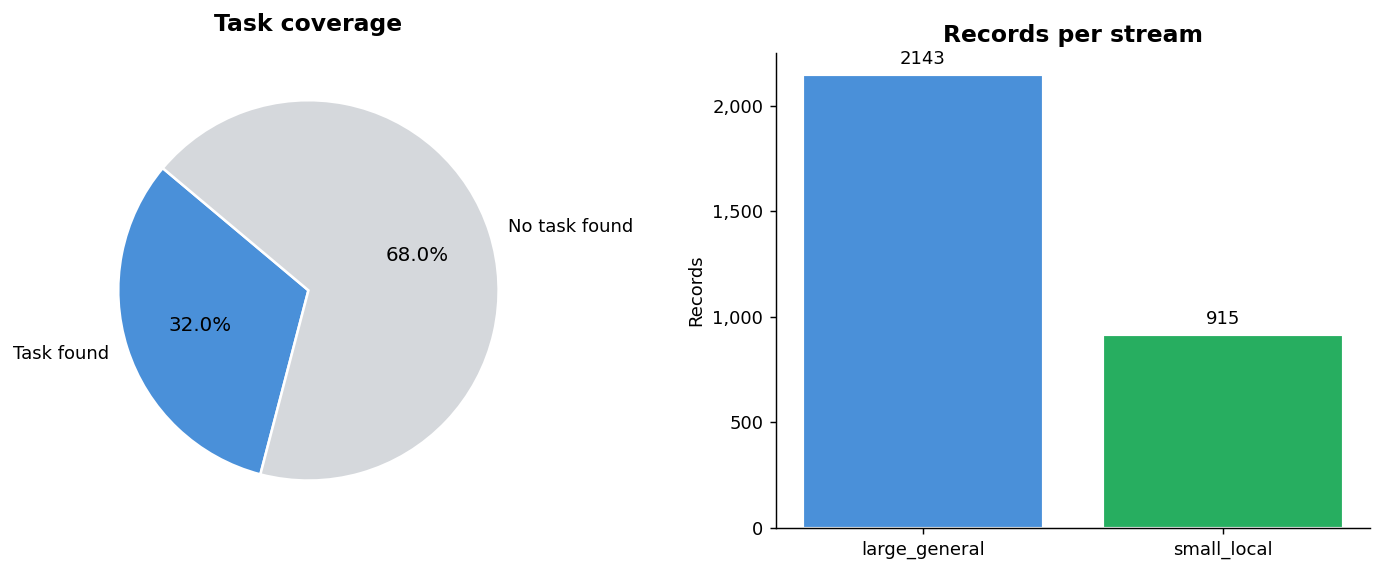

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# ── left: task vs no-task ─────────────────────────────────────────────────
ax = axes[0]
labels  = ['Task found', 'No task found']
sizes   = [(~df.no_task_found).sum(), df.no_task_found.sum()]
colors  = ['#4A90D9', '#D5D8DC']
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=140,
    wedgeprops=dict(linewidth=1.4, edgecolor='white'),
)
for at in autotexts:
    at.set_fontsize(11)
ax.set_title('Task coverage', fontsize=13, fontweight='bold', pad=12)

# ── right: records per stream ─────────────────────────────────────────────
ax2 = axes[1]
stream_counts = df['stream'].value_counts()
bars = ax2.bar(stream_counts.index, stream_counts.values,
               color=['#4A90D9', '#27AE60', '#E67E22'][:len(stream_counts)],
               edgecolor='white', linewidth=1.2)
ax2.bar_label(bars, fmt='%d', padding=4, fontsize=10)
ax2.set_title('Records per stream', fontsize=13, fontweight='bold')
ax2.set_ylabel('Records')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('fig_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

## 3 · Theme distribution

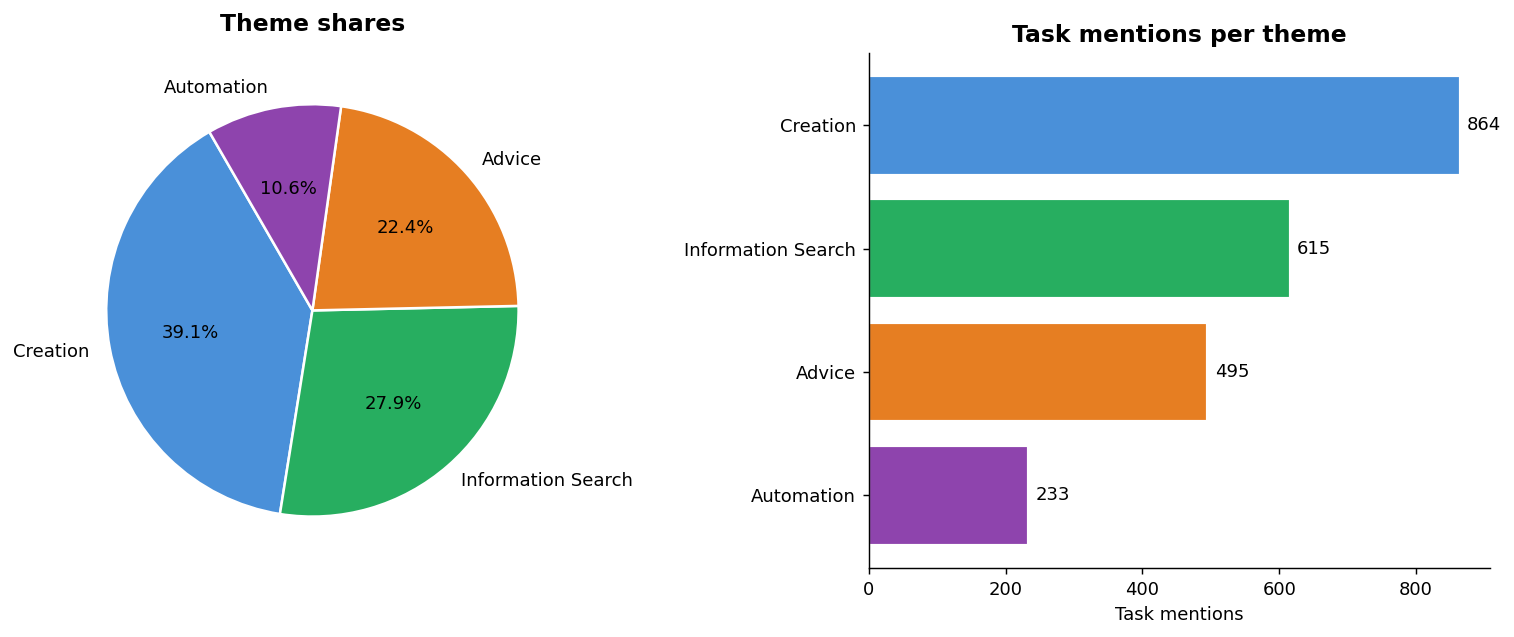

_themes
Creation              864
Information Search    615
Advice                495
Automation            233


In [6]:
theme_counts = task_rows['_themes'].value_counts().reindex(THEMES, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── pie ───────────────────────────────────────────────────────────────────
ax = axes[0]
colors = [THEME_COLORS.get(t, '#95A5A6') for t in theme_counts.index]
wedges, texts, autotexts = ax.pie(
    theme_counts.values, labels=theme_counts.index,
    colors=colors, autopct='%1.1f%%', startangle=120,
    wedgeprops=dict(linewidth=1.4, edgecolor='white'),
)
for at in autotexts:
    at.set_fontsize(10)
ax.set_title('Theme shares', fontsize=13, fontweight='bold', pad=12)

# ── bar ───────────────────────────────────────────────────────────────────
ax2 = axes[1]
bars = ax2.barh(theme_counts.index[::-1], theme_counts.values[::-1],
                color=[THEME_COLORS.get(t, '#95A5A6') for t in theme_counts.index[::-1]],
                edgecolor='white', linewidth=1.2)
ax2.bar_label(bars, fmt='%d', padding=4, fontsize=10)
ax2.set_title('Task mentions per theme', fontsize=13, fontweight='bold')
ax2.set_xlabel('Task mentions')
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('fig_themes.png', dpi=150, bbox_inches='tight')
plt.show()
print(theme_counts.to_string())

## 4 · Sub-theme distribution

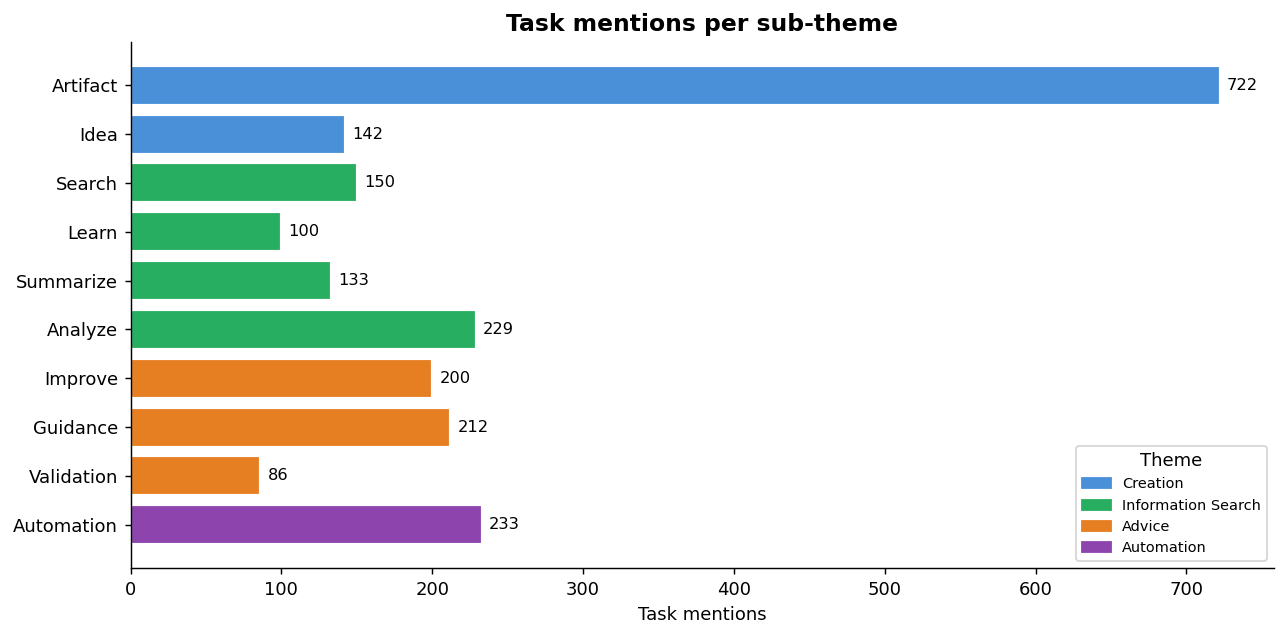

_subthemes
Artifact      722
Idea          142
Search        150
Learn         100
Summarize     133
Analyze       229
Improve       200
Guidance      212
Validation     86
Automation    233


In [7]:
subtheme_counts = task_rows['_subthemes'].value_counts().reindex(ALL_SUBTHEMES, fill_value=0)

# colour each bar according to its parent theme
subtheme_to_theme = {st: th for th, subs in SUBTHEMES.items() for st in subs}
bar_colors = [THEME_COLORS.get(subtheme_to_theme.get(st, ''), '#95A5A6')
              for st in subtheme_counts.index]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(subtheme_counts.index[::-1], subtheme_counts.values[::-1],
               color=bar_colors[::-1], edgecolor='white', linewidth=1.2)
ax.bar_label(bars, fmt='%d', padding=4, fontsize=9)
ax.set_title('Task mentions per sub-theme', fontsize=13, fontweight='bold')
ax.set_xlabel('Task mentions')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# legend for parent theme colours
import matplotlib.patches as mpatches
legend_patches = [mpatches.Patch(color=c, label=t) for t, c in THEME_COLORS.items()]
ax.legend(handles=legend_patches, title='Theme', fontsize=8,
          loc='lower right', framealpha=0.8)

plt.tight_layout()
plt.savefig('fig_subthemes.png', dpi=150, bbox_inches='tight')
plt.show()
print(subtheme_counts.to_string())

## 5 · Theme × Sub-theme heatmap

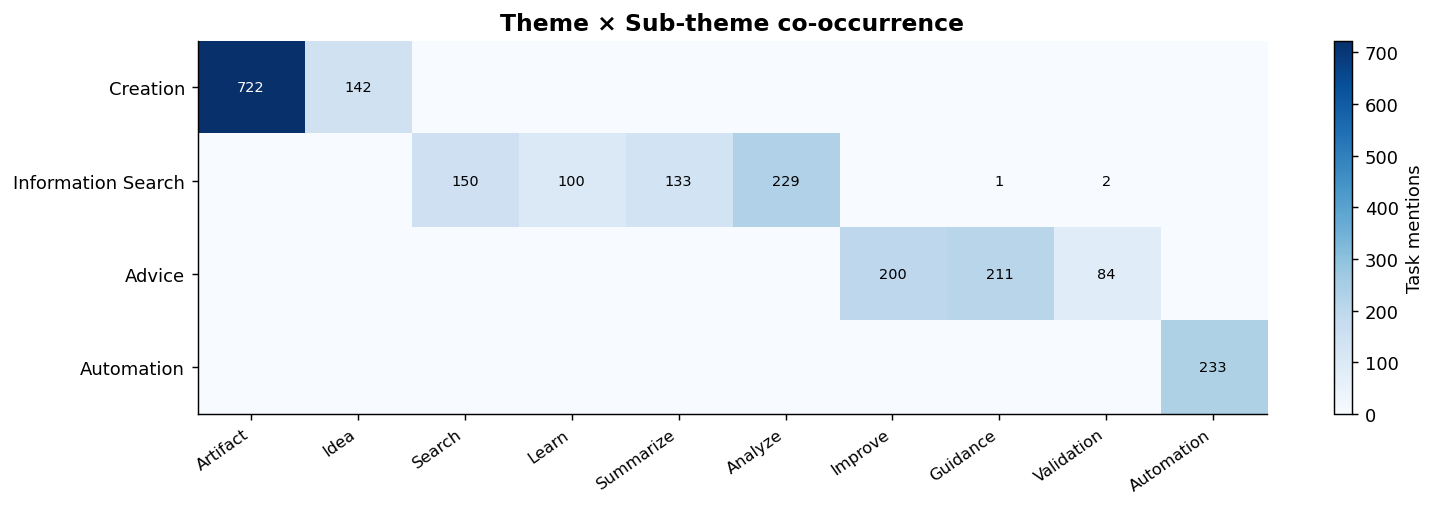

_subthemes          Artifact  Idea  Search  Learn  Summarize  Analyze  Improve  Guidance  Validation  Automation
_themes                                                                                                         
Creation                 722   142       0      0          0        0        0         0           0           0
Information Search         0     0     150    100        133      229        0         1           2           0
Advice                     0     0       0      0          0        0      200       211          84           0
Automation                 0     0       0      0          0        0        0         0           0         233


In [8]:
pivot = (
    task_rows
    .groupby(['_themes', '_subthemes'])
    .size()
    .unstack(fill_value=0)
    .reindex(index=THEMES, columns=ALL_SUBTHEMES, fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(pivot.values, aspect='auto', cmap='Blues')
plt.colorbar(im, ax=ax, label='Task mentions')

ax.set_xticks(range(len(ALL_SUBTHEMES)))
ax.set_xticklabels(ALL_SUBTHEMES, rotation=35, ha='right', fontsize=9)
ax.set_yticks(range(len(THEMES)))
ax.set_yticklabels(THEMES, fontsize=10)

# annotate cells
for i, theme in enumerate(THEMES):
    for j, sub in enumerate(ALL_SUBTHEMES):
        val = pivot.loc[theme, sub] if sub in pivot.columns else 0
        if val > 0:
            ax.text(j, i, str(val), ha='center', va='center',
                    fontsize=8, color='black' if val < pivot.values.max()*0.6 else 'white')

ax.set_title('Theme × Sub-theme co-occurrence', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(pivot.to_string())

## 6 · Top tasks overall

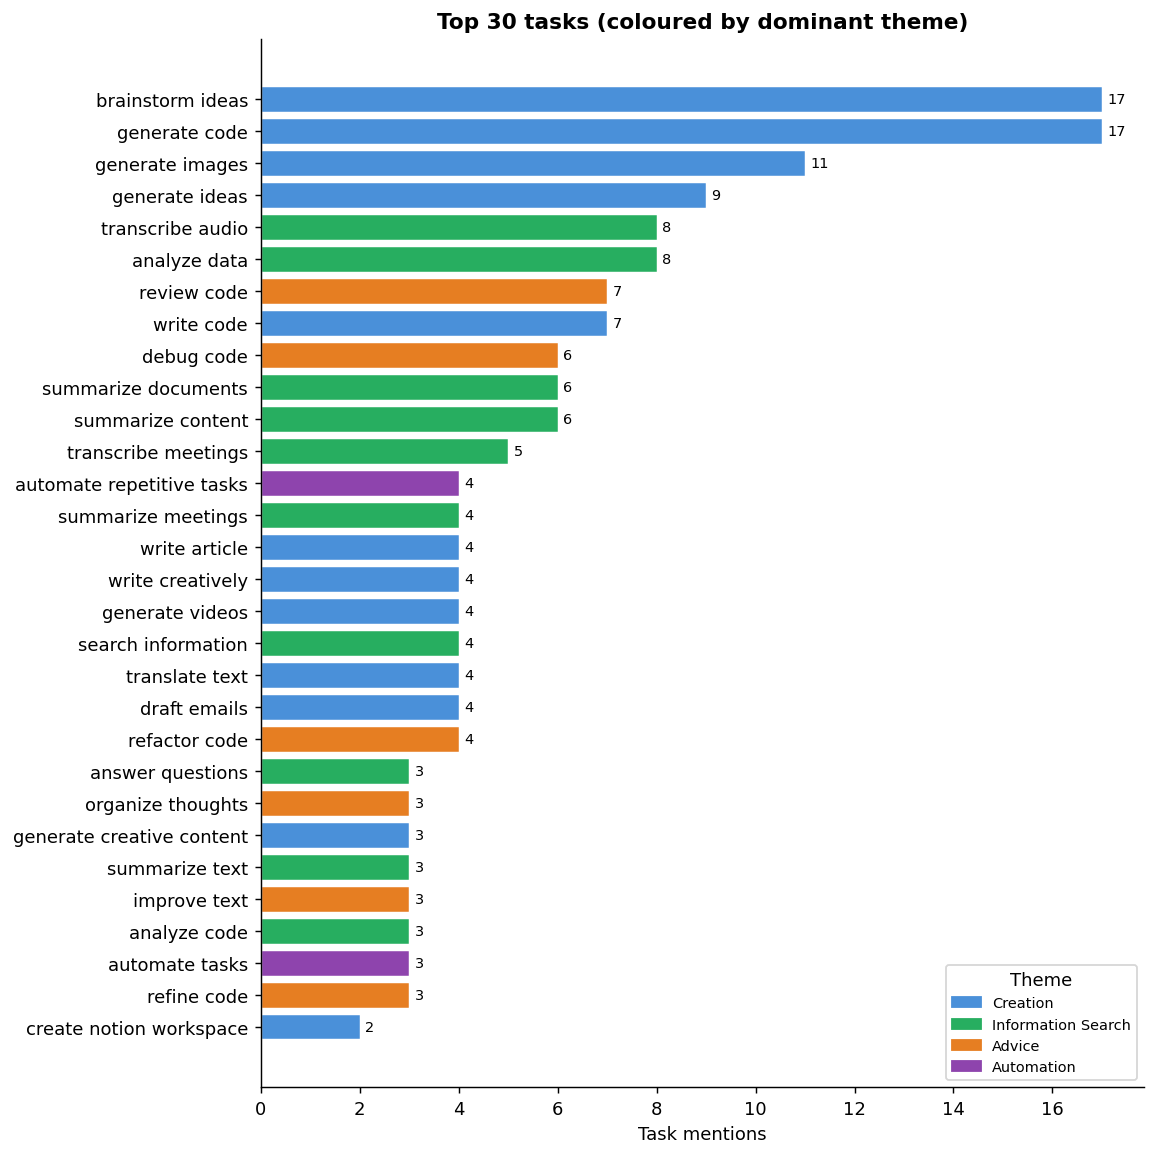

In [9]:
TOP_N = 30
task_counts = task_rows['_tasks'].str.lower().value_counts()
top = task_counts.head(TOP_N).sort_values()

fig, ax = plt.subplots(figsize=(9, 9))
colors_top = []
for t in top.index:
    # find dominant theme for this task label
    mask = task_rows['_tasks'].str.lower() == t
    dominant = task_rows.loc[mask, '_themes'].mode()
    theme = dominant.iloc[0] if len(dominant) else ''
    colors_top.append(THEME_COLORS.get(theme, '#95A5A6'))

bars = ax.barh(top.index, top.values, color=colors_top,
               edgecolor='white', linewidth=0.8)
ax.bar_label(bars, fmt='%d', padding=3, fontsize=8)
ax.set_title(f'Top {TOP_N} tasks (coloured by dominant theme)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Task mentions')

legend_patches = [mpatches.Patch(color=c, label=t) for t, c in THEME_COLORS.items()]
ax.legend(handles=legend_patches, title='Theme', fontsize=8,
          loc='lower right', framealpha=0.8)

plt.tight_layout()
plt.savefig('fig_top_tasks.png', dpi=150, bbox_inches='tight')
plt.show()

## 7 · Top tasks per theme

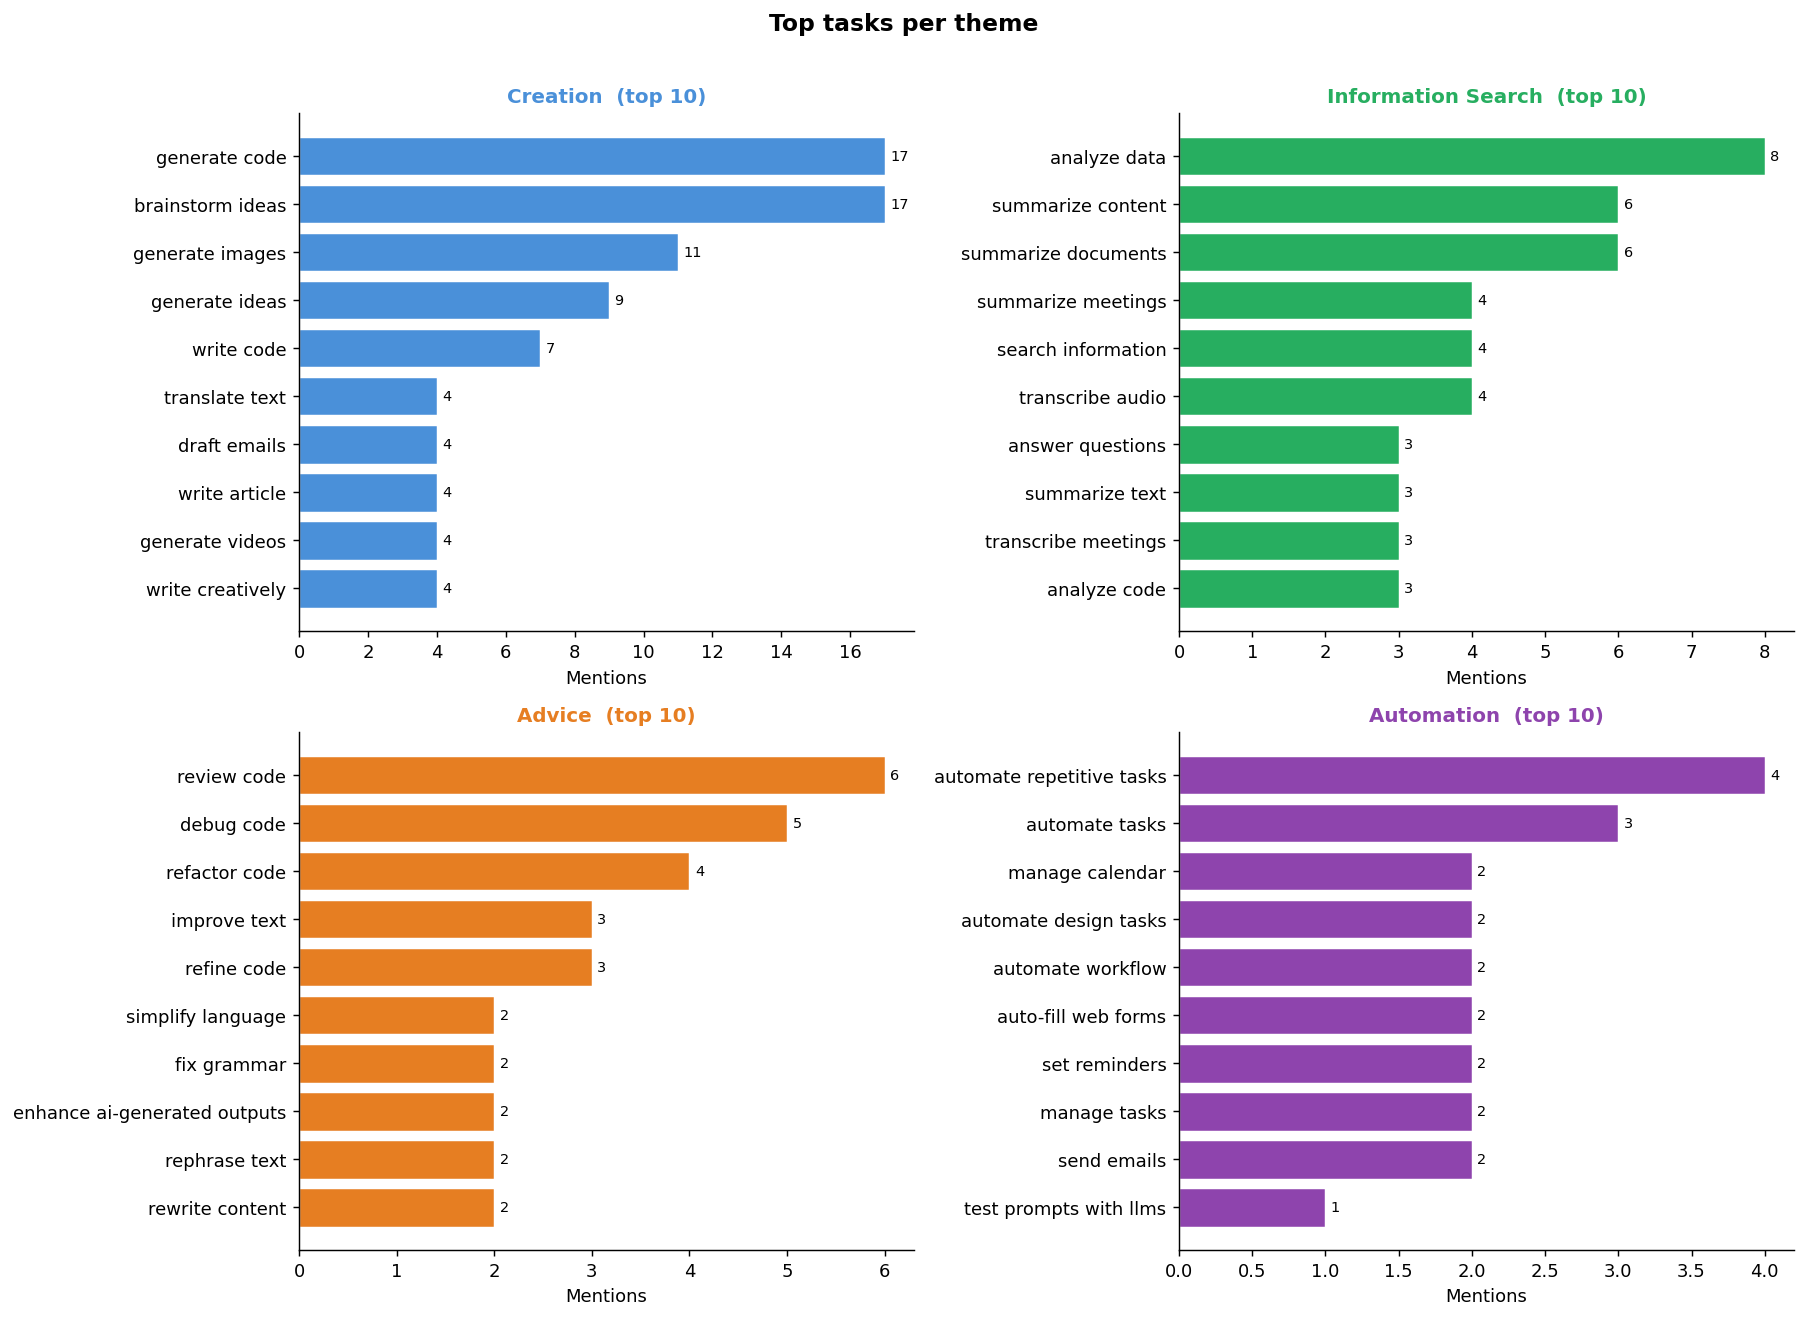

In [10]:
TOP_PER_THEME = 10

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, theme in zip(axes, THEMES):
    subset = task_rows[task_rows['_themes'] == theme]
    counts = subset['_tasks'].str.lower().value_counts().head(TOP_PER_THEME).sort_values()
    color  = THEME_COLORS.get(theme, '#95A5A6')

    bars = ax.barh(counts.index, counts.values,
                   color=color, edgecolor='white', linewidth=0.8)
    ax.bar_label(bars, fmt='%d', padding=3, fontsize=8)
    ax.set_title(f'{theme}  (top {TOP_PER_THEME})', fontsize=11, fontweight='bold',
                 color=color)
    ax.set_xlabel('Mentions')

plt.suptitle('Top tasks per theme', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig_top_per_theme.png', dpi=150, bbox_inches='tight')
plt.show()

## 8 · Stream 1 vs Stream 2 — theme comparison

/tmp/ipykernel_6744/216951860.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tc.index, rotation=20, ha='right')
/tmp/ipykernel_6744/216951860.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tc.index, rotation=20, ha='right')


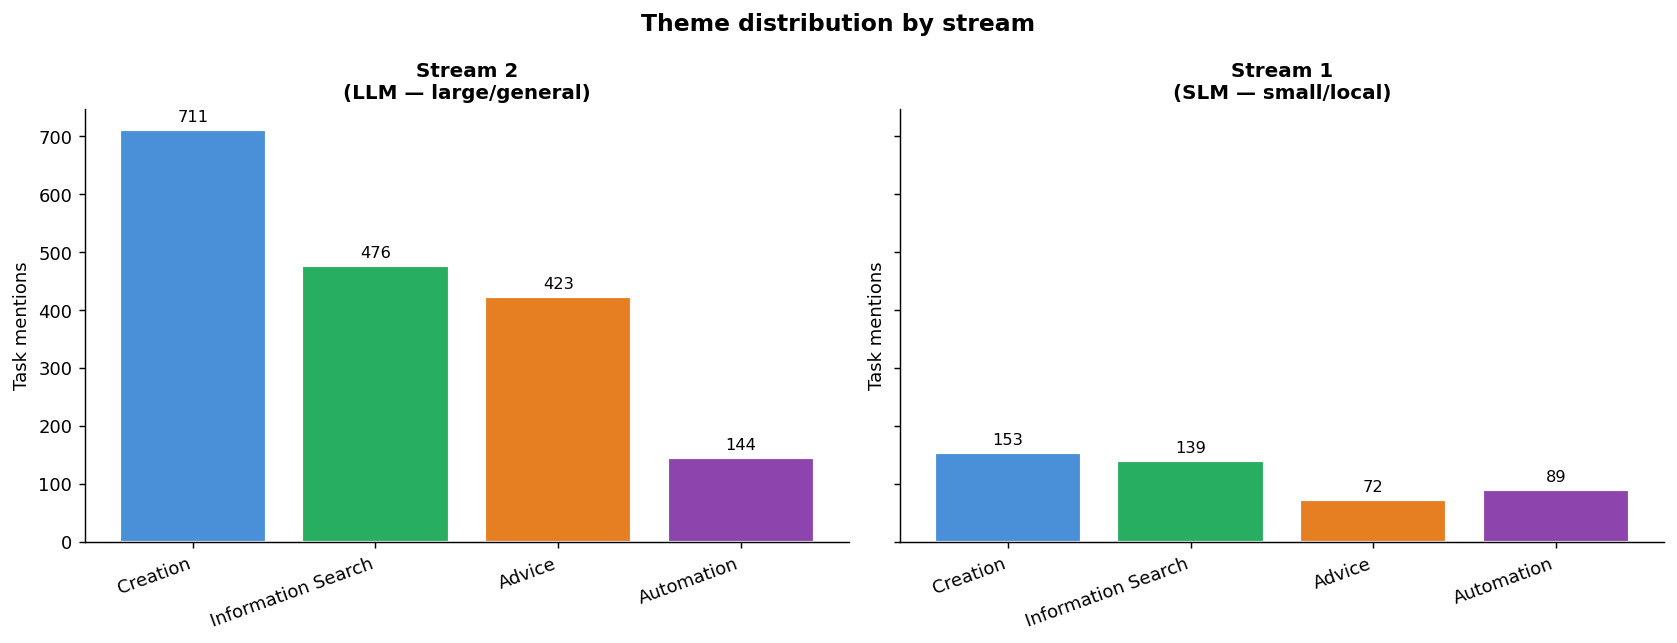

In [11]:
STREAM_LABELS = {
    'small_local':   'Stream 1\n(SLM — small/local)',
    'large_general': 'Stream 2\n(LLM — large/general)',
}

streams = task_rows['stream'].unique()

if len(streams) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
    for ax, stream in zip(axes, sorted(streams)):
        sub = task_rows[task_rows['stream'] == stream]
        tc  = sub['_themes'].value_counts().reindex(THEMES, fill_value=0)
        colors = [THEME_COLORS.get(t, '#95A5A6') for t in tc.index]
        bars = ax.bar(tc.index, tc.values, color=colors,
                      edgecolor='white', linewidth=1.2)
        ax.bar_label(bars, fmt='%d', padding=3, fontsize=9)
        label = STREAM_LABELS.get(stream, stream)
        ax.set_title(label, fontsize=11, fontweight='bold')
        ax.set_ylabel('Task mentions')
        ax.set_xticklabels(tc.index, rotation=20, ha='right')
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

    plt.suptitle('Theme distribution by stream', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig_stream_themes.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Only one stream detected — skipping comparison chart.')
    print('Streams found:', streams)

## 9 · Stream overlap — shared vs. exclusive tasks

Stream 1 unique (norm) : 1,177
Stream 2 unique (norm) : 329
Shared                 : 38
Exclusive to Stream 1  : 1,139
Exclusive to Stream 2  : 291


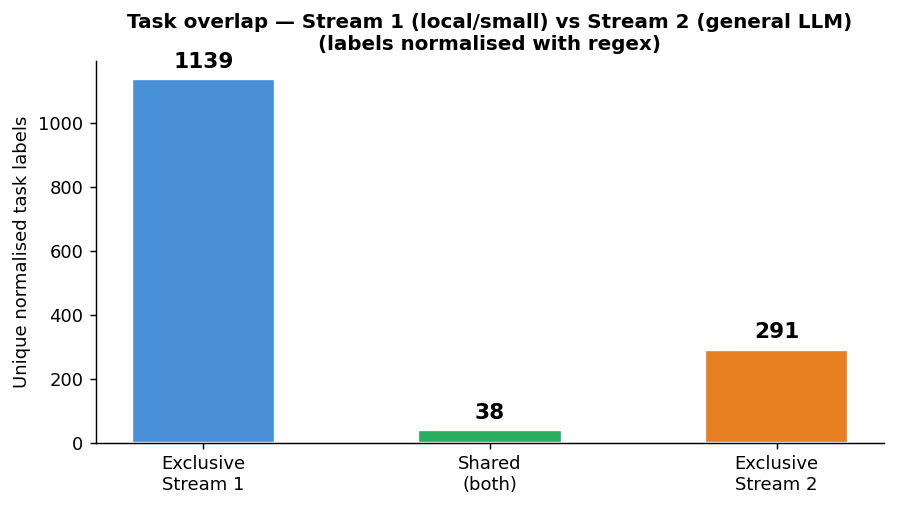

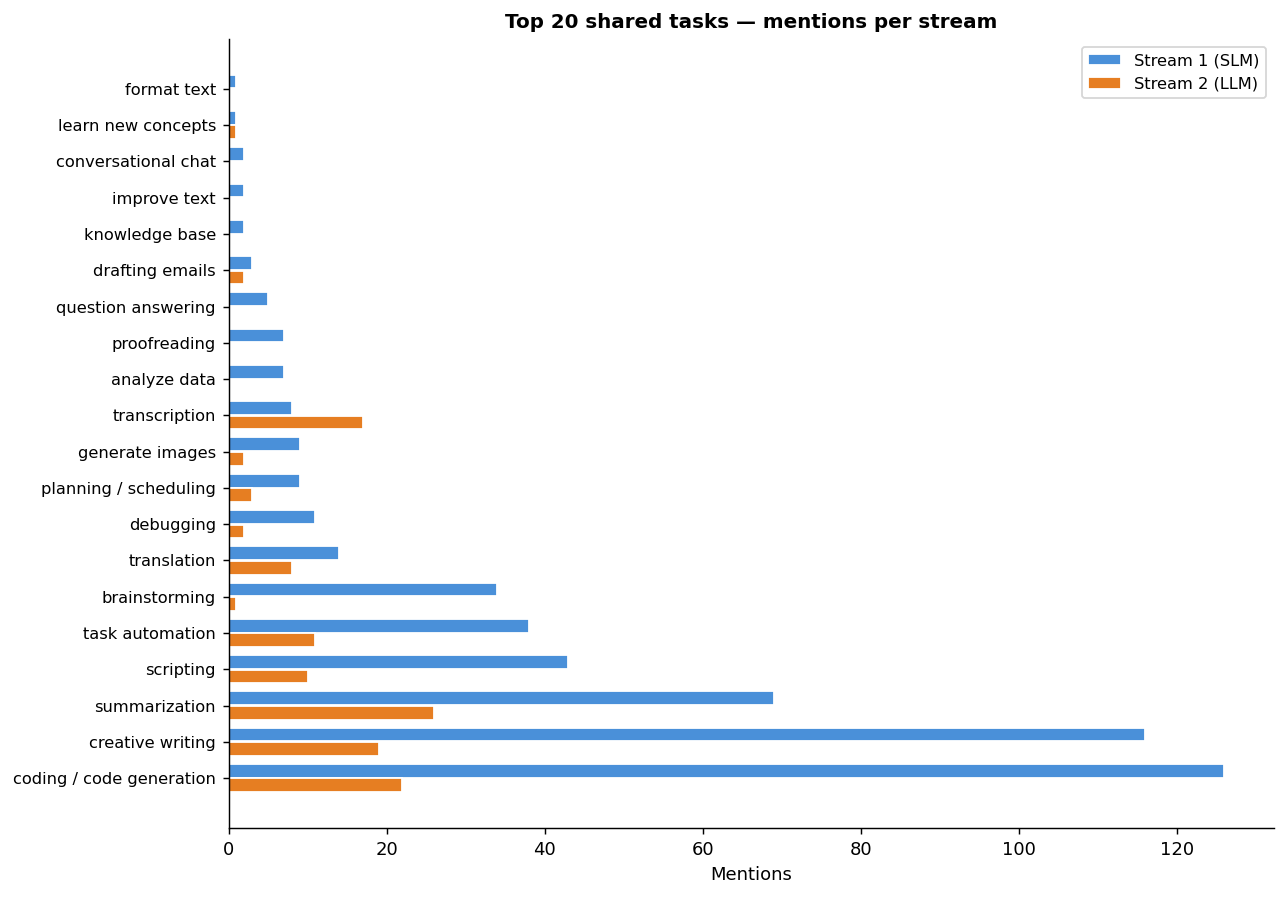

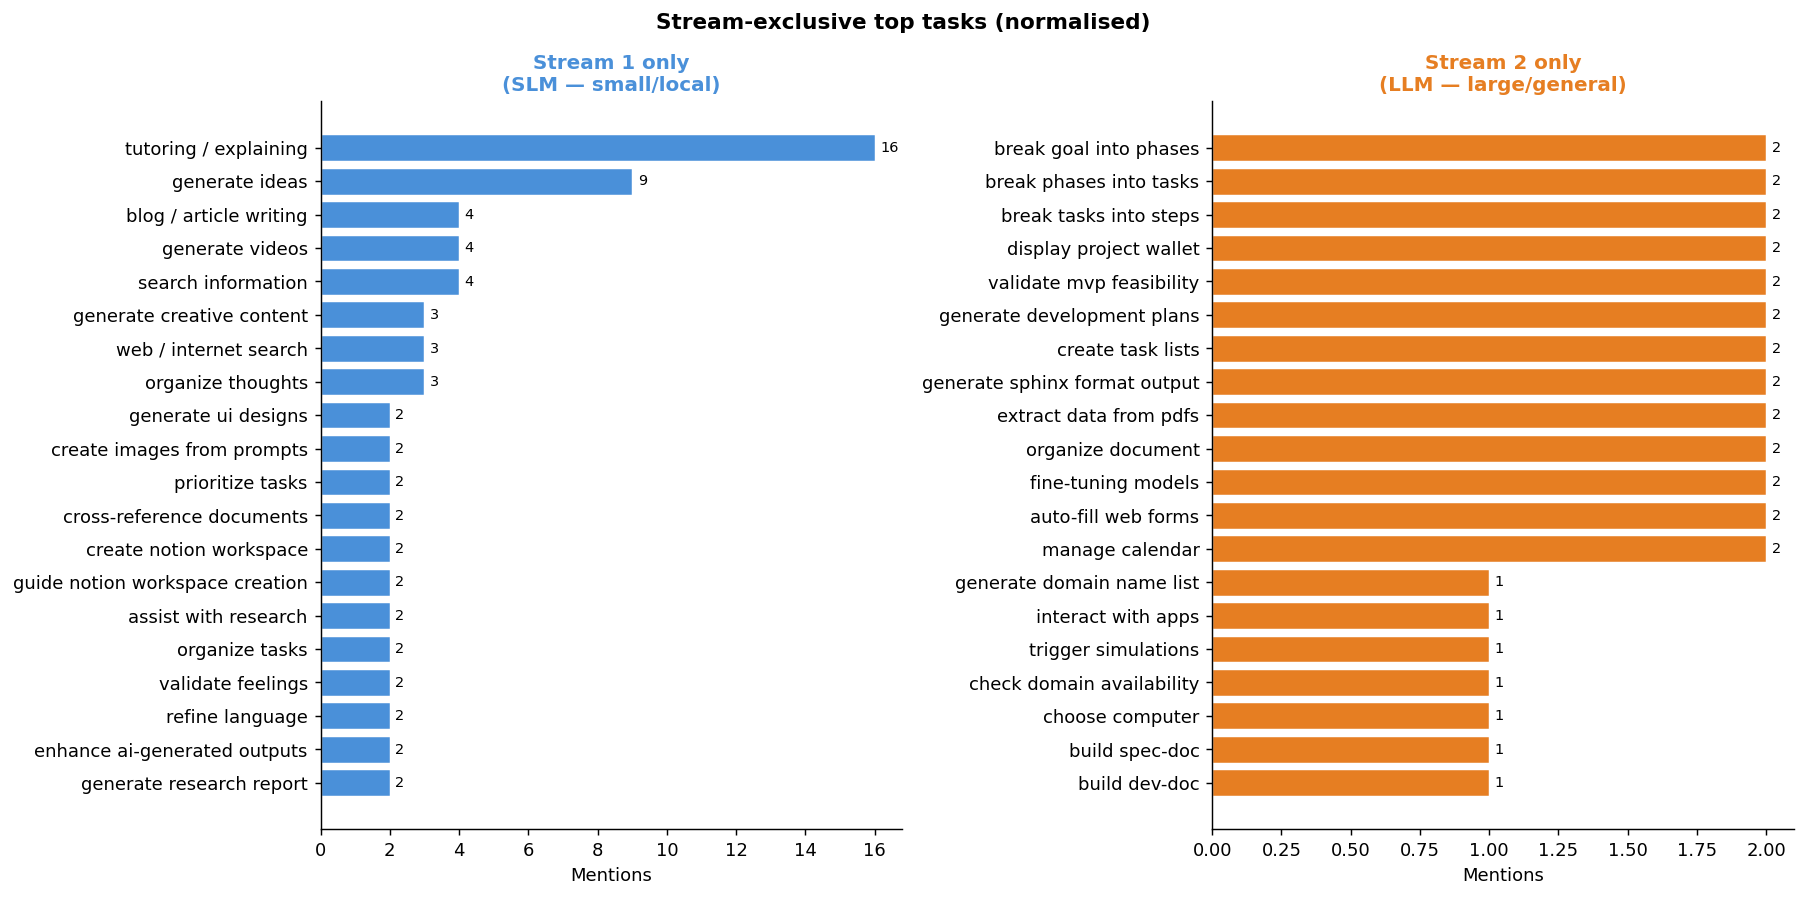

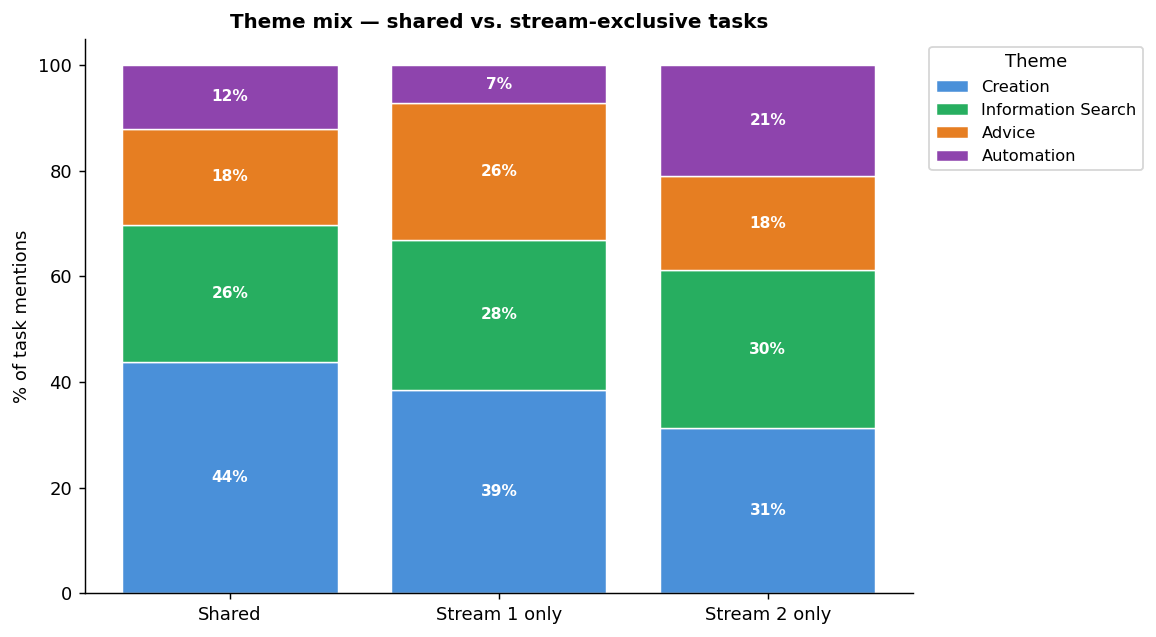


── Theme distribution (raw counts) ──────────────────────────
                    Shared  Stream 1 only  Stream 2 only
Creation               295            474             95
Information Search     175            349             91
Advice                 123            318             54
Automation              81             88             64


In [12]:
# ── build per-stream task sets (using NORMALISED labels) ────────────────
def norm_tasks_for_stream(stream_val):
    mask = task_rows['stream'] == stream_val
    return set(task_rows.loc[mask, '_task_norm'].dropna())

streams_present = sorted(task_rows['stream'].dropna().unique())
if len(streams_present) < 2:
    print('Only one stream present; skipping overlap analysis.')
else:
    s1_label, s2_label = streams_present[0], streams_present[1]
    tasks_s1 = norm_tasks_for_stream(s1_label)
    tasks_s2 = norm_tasks_for_stream(s2_label)
    shared      = tasks_s1 & tasks_s2
    only_s1     = tasks_s1 - tasks_s2
    only_s2     = tasks_s2 - tasks_s1

    print(f'Stream 1 unique (norm) : {len(tasks_s1):,}')
    print(f'Stream 2 unique (norm) : {len(tasks_s2):,}')
    print(f'Shared                 : {len(shared):,}')
    print(f'Exclusive to Stream 1  : {len(only_s1):,}')
    print(f'Exclusive to Stream 2  : {len(only_s2):,}')

    # ── helper: mention counts within a stream for a given task set ───────
    def mention_counts(stream_val, task_set, top_n=20):
        mask = task_rows['stream'] == stream_val
        sub  = task_rows.loc[mask & task_rows['_task_norm'].isin(task_set)]
        return sub['_task_norm'].value_counts().head(top_n)

    shared_s1_counts = mention_counts(s1_label, shared)
    shared_s2_counts = mention_counts(s2_label, shared)
    excl_s1_counts   = mention_counts(s1_label, only_s1)
    excl_s2_counts   = mention_counts(s2_label, only_s2)

    # ── Figure 1: Venn-style bar ──────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(7, 4))
    categories = ['Exclusive\nStream 1', 'Shared\n(both)', 'Exclusive\nStream 2']
    values     = [len(only_s1), len(shared), len(only_s2)]
    bar_colors = ['#4A90D9', '#27AE60', '#E67E22']
    bars = ax.bar(categories, values, color=bar_colors,
                  edgecolor='white', linewidth=1.3, width=0.5)
    ax.bar_label(bars, fmt='%d', padding=4, fontsize=12, fontweight='bold')
    ax.set_title(
        'Task overlap — Stream 1 (local/small) vs Stream 2 (general LLM)\n'
        '(labels normalised with regex)',
        fontsize=11, fontweight='bold')
    ax.set_ylabel('Unique normalised task labels')
    plt.tight_layout()
    plt.savefig('fig_overlap_venn.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Figure 2: Top shared tasks — side-by-side mention counts ──────────
    TOP = 20
    common_tasks = shared_s1_counts.index[:TOP]
    s1_vals = shared_s1_counts.reindex(common_tasks, fill_value=0)
    s2_vals = shared_s2_counts.reindex(common_tasks, fill_value=0)

    fig, ax = plt.subplots(figsize=(10, 7))
    y = range(len(common_tasks))
    ax.barh([i + 0.2 for i in y], s1_vals.values, height=0.38,
            color='#4A90D9', label='Stream 1 (SLM)', edgecolor='white')
    ax.barh([i - 0.2 for i in y], s2_vals.values, height=0.38,
            color='#E67E22', label='Stream 2 (LLM)', edgecolor='white')
    ax.set_yticks(list(y))
    ax.set_yticklabels(common_tasks, fontsize=9)
    ax.set_xlabel('Mentions')
    ax.set_title(f'Top {TOP} shared tasks — mentions per stream',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig('fig_overlap_shared.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Figure 3: Exclusive tasks per stream ──────────────────────────────
    TOP_EXCL = 20
    fig, axes = plt.subplots(1, 2, figsize=(14, 7))
    for ax, counts, color, label in [
        (axes[0], excl_s1_counts.head(TOP_EXCL).sort_values(),
         '#4A90D9', 'Stream 1 only\n(SLM — small/local)'),
        (axes[1], excl_s2_counts.head(TOP_EXCL).sort_values(),
         '#E67E22', 'Stream 2 only\n(LLM — large/general)'),
    ]:
        bars = ax.barh(counts.index, counts.values,
                       color=color, edgecolor='white', linewidth=0.8)
        ax.bar_label(bars, fmt='%d', padding=3, fontsize=8)
        ax.set_title(label, fontsize=11, fontweight='bold', color=color)
        ax.set_xlabel('Mentions')
    plt.suptitle('Stream-exclusive top tasks (normalised)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig_overlap_exclusive.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Figure 4: Theme mix — stacked 100% bar ────────────────────────────
    def theme_dist(stream_val, task_set=None):
        mask = task_rows['stream'] == stream_val
        if task_set is not None:
            mask = mask & task_rows['_task_norm'].isin(task_set)
        return task_rows.loc[mask, '_themes'].value_counts().reindex(THEMES, fill_value=0)

    cats = ['Shared', 'Stream 1 only', 'Stream 2 only']
    data = {
        'Shared':        theme_dist(s1_label, shared) + theme_dist(s2_label, shared),
        'Stream 1 only': theme_dist(s1_label, only_s1),
        'Stream 2 only': theme_dist(s2_label, only_s2),
    }
    theme_df  = pd.DataFrame(data, index=THEMES)
    theme_pct = theme_df.div(theme_df.sum(axis=0), axis=1) * 100

    fig, ax = plt.subplots(figsize=(9, 5))
    bottom = np.zeros(len(cats))
    for theme in THEMES:
        vals = theme_pct.loc[theme].values
        bars = ax.bar(cats, vals, bottom=bottom,
                      color=THEME_COLORS[theme], label=theme,
                      edgecolor='white', linewidth=0.8)
        for bar, val in zip(bars, vals):
            if val > 4:
                ax.text(bar.get_x() + bar.get_width()/2,
                        bar.get_y() + bar.get_height()/2,
                        f'{val:.0f}%', ha='center', va='center',
                        fontsize=8.5, color='white', fontweight='bold')
        bottom += vals
    ax.set_ylabel('% of task mentions')
    ax.set_title('Theme mix — shared vs. stream-exclusive tasks',
                 fontsize=11, fontweight='bold')
    ax.legend(title='Theme', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
    ax.set_ylim(0, 105)
    plt.tight_layout()
    plt.savefig('fig_overlap_theme_mix.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\n── Theme distribution (raw counts) ──────────────────────────')
    print(theme_df.to_string())

## 10 · Submissions vs Comments — theme breakdown

/tmp/ipykernel_6744/1786711611.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tc.index, rotation=20, ha='right')
/tmp/ipykernel_6744/1786711611.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tc.index, rotation=20, ha='right')


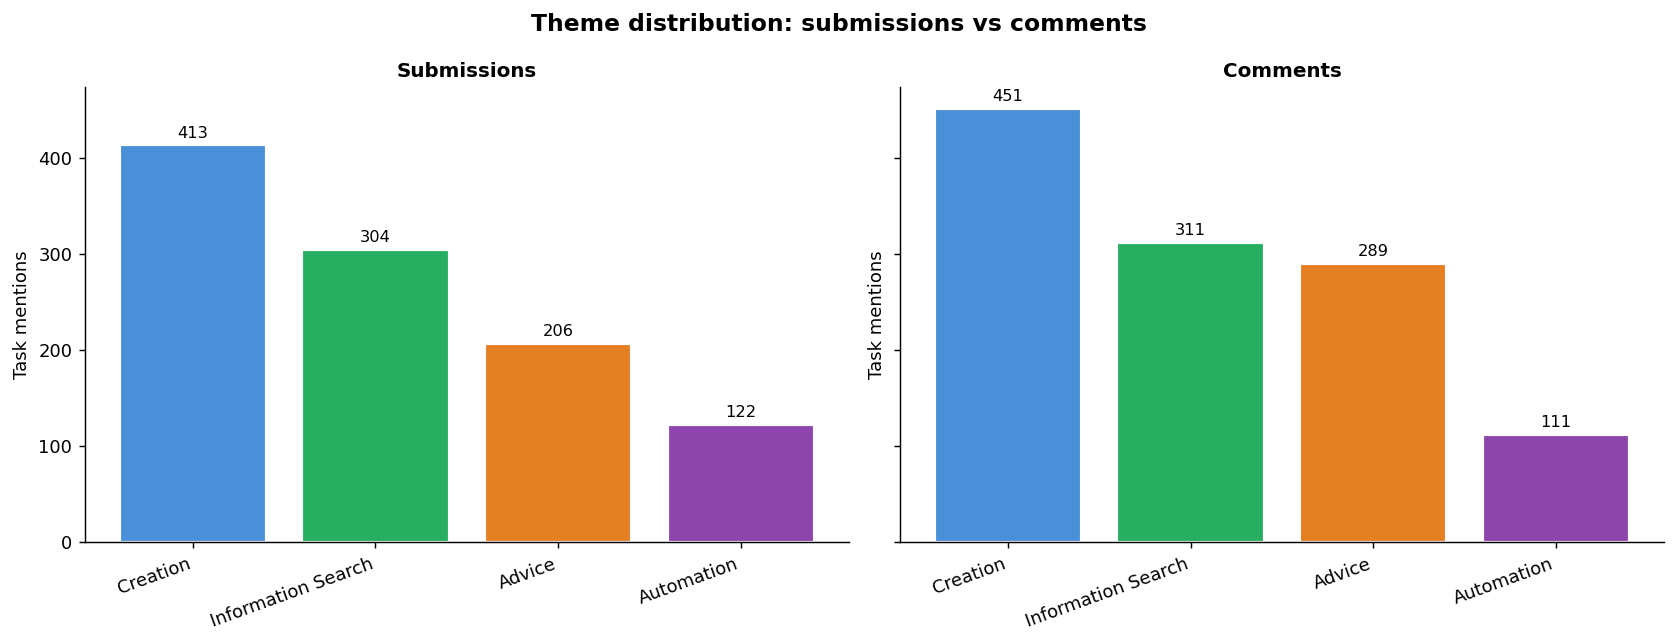

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for ax, kind in zip(axes, ['submission', 'comment']):
    sub = task_rows[task_rows['kind'] == kind]
    tc  = sub['_themes'].value_counts().reindex(THEMES, fill_value=0)
    colors = [THEME_COLORS.get(t, '#95A5A6') for t in tc.index]
    bars = ax.bar(tc.index, tc.values, color=colors,
                  edgecolor='white', linewidth=1.2)
    ax.bar_label(bars, fmt='%d', padding=3, fontsize=9)
    ax.set_title(kind.capitalize() + 's', fontsize=11, fontweight='bold')
    ax.set_ylabel('Task mentions')
    ax.set_xticklabels(tc.index, rotation=20, ha='right')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.suptitle('Theme distribution: submissions vs comments',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_kind_themes.png', dpi=150, bbox_inches='tight')
plt.show()

## 11 · Per-subreddit theme distribution

/tmp/ipykernel_6744/3797715593.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tc.index, rotation=25, ha='right', fontsize=8)
/tmp/ipykernel_6744/3797715593.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tc.index, rotation=25, ha='right', fontsize=8)
/tmp/ipykernel_6744/3797715593.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tc.index, rotation=25, ha='right', fontsize=8)
/tmp/ipykernel_6744/3797715593.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(tc.index, rotation=25, ha='right', fontsize=8)
/tmp/ipykernel_6744/3797715593.py:18: UserWarning: set_ticklabel

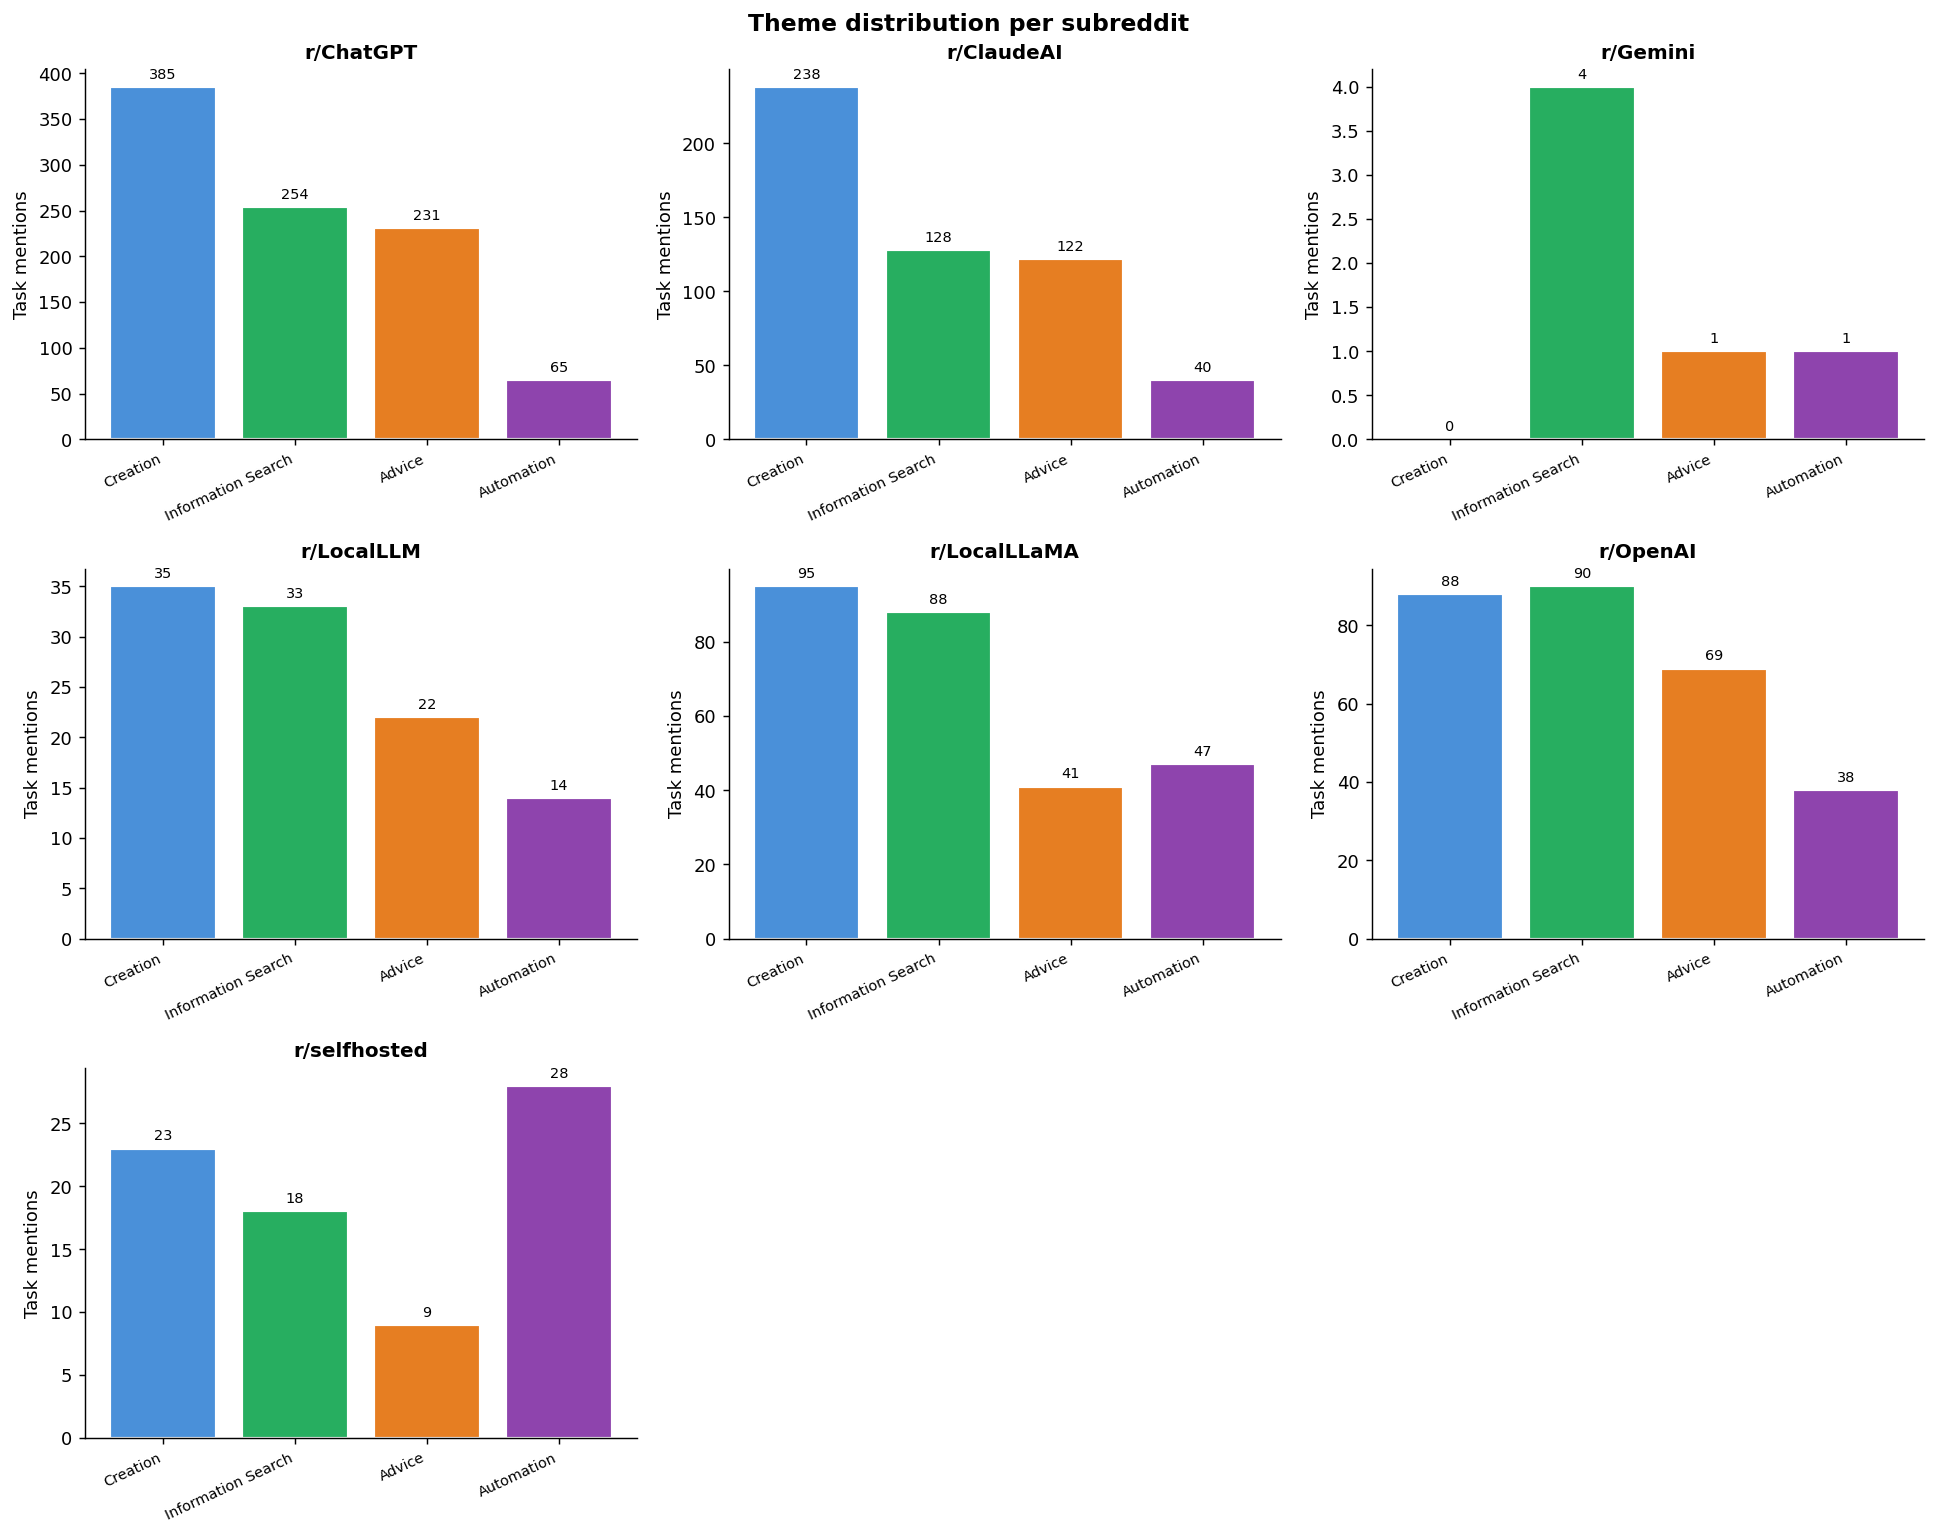

In [14]:
subreddits = sorted(task_rows['subreddit'].dropna().unique())
n = len(subreddits)
ncols = min(n, 3)
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharey=False)
axes = np.array(axes).flatten() if n > 1 else [axes]

for ax, sub in zip(axes, subreddits):
    mask = task_rows['subreddit'].str.lower() == sub.lower()
    tc   = task_rows.loc[mask, '_themes'].value_counts().reindex(THEMES, fill_value=0)
    colors = [THEME_COLORS.get(t, '#95A5A6') for t in tc.index]
    bars = ax.bar(tc.index, tc.values, color=colors,
                  edgecolor='white', linewidth=1.2)
    ax.bar_label(bars, fmt='%d', padding=3, fontsize=8)
    ax.set_title(f'r/{sub}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Task mentions')
    ax.set_xticklabels(tc.index, rotation=25, ha='right', fontsize=8)

for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle('Theme distribution per subreddit', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_subreddit_themes.png', dpi=150, bbox_inches='tight')
plt.show()

## 15 · Export clean task summary

In [15]:
out_path = Path('task_summary.csv')
task_table.to_csv(out_path, index=False)
print(f'Saved → {out_path}  ({len(task_table):,} rows)')
task_table.head(20)

NameError: name 'task_table' is not defined

## 16 · Export shared-task records for manual annotation

Filters every original record whose normalised task label appears in **both** streams,
excluding `coding / code generation` (too broad to be informative).
Writes two files — one per stream — ready for manual labelling.

In [ ]:
EXCLUDE_TASKS = {'coding / code generation'}

# shared must already be computed by §9; guard in case cells run out of order
if 'shared' not in dir():
    raise RuntimeError('Run §9 (Stream overlap) first so `shared` is defined.')

shared_filtered = shared - EXCLUDE_TASKS
print(f'Shared tasks used for export ({len(shared_filtered)}):'
      f'\n  ' + '\n  '.join(sorted(shared_filtered)))

# ── columns to keep for manual annotation ────────────────────────────────
KEEP_COLS = [
    'id', 'kind', 'subreddit', 'date', 'stream',
    'title', 'body', 'url', 'score',
    '_task_norm', '_tasks', '_themes', '_subthemes', 'evidence',
    'annotation_notes',
]
KEEP_COLS = [c for c in KEEP_COLS if c in task_rows.columns]

# ── filter rows whose normalised task is in the shared set ───────────────
mask_shared = task_rows['_task_norm'].isin(shared_filtered)
shared_rows = task_rows.loc[mask_shared, KEEP_COLS].copy()

# rename internal columns to friendly names
shared_rows = shared_rows.rename(columns={
    '_task_norm':   'task_canonical',
    '_tasks':       'task_raw',
    '_themes':      'theme',
    '_subthemes':   'subtheme',
})

# ── split by stream ───────────────────────────────────────────────────────
# stream values are alphabetically sorted, so s1_label='large_general' (LLM)
# and s2_label='small_local' (SLM) — use explicit constants to avoid the swap
SLM_STREAM = 'small_local'
LLM_STREAM = 'large_general'
slm_df = shared_rows[shared_rows['stream'] == SLM_STREAM].reset_index(drop=True)
llm_df = shared_rows[shared_rows['stream'] == LLM_STREAM].reset_index(drop=True)

# add a blank column for the annotator to fill in
for df_out in (slm_df, llm_df):
    df_out.insert(0, 'manual_label', '')
    df_out.insert(1, 'manual_notes', '')

# ── write files ───────────────────────────────────────────────────────────
slm_path = Path('slm_shared_tasks.csv')
llm_path = Path('llm_shared_tasks.csv')
slm_df.to_csv(slm_path, index=False)
llm_df.to_csv(llm_path, index=False)

print(f'\nWrote {len(slm_df):,} rows → {slm_path}')
print(f'Wrote {len(llm_df):,} rows → {llm_path}')
print(f'\nTask breakdown — SLM file:')
print(slm_df['task_canonical'].value_counts().to_string())
print(f'\nTask breakdown — LLM file:')
print(llm_df['task_canonical'].value_counts().to_string())

Shared tasks used for export (10):
  brainstorming
  creative writing
  fine-tuning models
  planning / scheduling
  proofreading
  scripting
  summarization
  task automation
  transcription
  translation

Wrote 30 rows → slm_shared_tasks.csv
Wrote 98 rows → llm_shared_tasks.csv

Task breakdown — SLM file:
task_canonical
creative writing         9
summarization            6
task automation          6
scripting                2
brainstorming            2
transcription            1
planning / scheduling    1
proofreading             1
translation              1
fine-tuning models       1

Task breakdown — LLM file:
task_canonical
summarization            26
creative writing         19
transcription            17
task automation          11
scripting                10
translation               8
planning / scheduling     3
fine-tuning models        2
brainstorming             1
proofreading              1
